1. Installing Necessary libraries

In [1]:
%pip install xgboost 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
!{sys.executable} -m pip install xgboost


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os
import json
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import shap

print("Pandas:", pd.__version__)
print("Sklearn ready")
print("SHAP:", shap.__version__)


Pandas: 3.0.1
Sklearn ready
SHAP: 0.50.0


2.Configuration

In [4]:
TRAIN_PATH = r"train\train.csv"

RANDOM_STATE = 42
CHUNKSIZE = 250_000

# Sampling limits so the experiment runs on a normal laptop
BASELINE_SAMPLE_ROWS = 400_000
ZERO_DAY_TRAIN_ROWS = 400_000
ZERO_DAY_TEST_ROWS = 200_000

# Zero-day attacks are excluded from training and used only for zero-day testing
ZERO_DAY_ATTACKS = {
    "SqlInjection",
    "XSS",
    "CommandInjection",
    "BrowserHijacking",
    "Uploading_Attack",
    "Backdoor_Malware",
    "DictionaryBruteForce",
}

def make_binary_y(label: str) -> int:
    """BenignTraffic = 0, all attack classes = 1."""
    return 0 if label == "BenignTraffic" else 1

def prepare_xy(df: pd.DataFrame):
    """Separate features and target, ensure numeric features, handle missing values."""
    y = df["y"].astype(int)
    X = df.drop(columns=["label", "y"], errors="ignore")
    X = X.apply(pd.to_numeric, errors="coerce").fillna(0)
    return X, y


3.Dataset Inspection

In [5]:
sample = pd.read_csv(TRAIN_PATH, nrows=5)
print("Shape of small sample:", sample.shape)
print("Columns:", list(sample.columns))
sample.head()


Shape of small sample: (5, 47)
Columns: ['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight', 'label']


,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,0.000000,757.00,6.00,64.00,23.671858,23.671858,0.0,0.0,0.0,0.0,...,538.470740,944.00,8.334058e+07,9.5,41.845546,761.456760,305219.322301,0.95,141.55,DDoS-ACK_Fragmentation
1,0.000000,54.00,6.00,64.00,2.393046,2.393046,0.0,0.0,1.0,0.0,...,0.000000,54.00,8.309327e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-SYN_Flood
2,0.033982,56.78,6.11,64.64,1.192715,1.192715,0.0,0.0,0.0,0.0,...,1.727526,54.29,8.333086e+07,9.5,10.462813,2.445286,16.853118,0.19,141.55,DDoS-PSHACK_Flood
3,0.000000,0.00,47.00,64.00,9.841972,9.841972,0.0,0.0,0.0,0.0,...,0.000000,592.00,8.370278e+07,9.5,34.409301,0.000000,0.000000,0.00,141.55,Mirai-greeth_flood
4,3.944828,108.00,6.00,64.00,0.506993,0.506993,0.0,0.0,1.0,0.0,...,0.000000,54.00,8.297270e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DoS-SYN_Flood


4. Dataset statistics using Chunk loading

In [6]:
# This counts total rows and label distribution without loading the full dataset at once.

total_rows = 0
label_counts = Counter()
missing_counts = None

for chunk in pd.read_csv(TRAIN_PATH, chunksize=CHUNKSIZE):
    total_rows += len(chunk)
    label_counts.update(chunk["label"])

    chunk_missing = chunk.isnull().sum()
    if missing_counts is None:
        missing_counts = chunk_missing
    else:
        missing_counts += chunk_missing

print("Total rows:", total_rows)
print("Number of unique labels:", len(label_counts))
print("\nTop 20 labels:")
for label, count in label_counts.most_common(20):
    print(f"{label}: {count}")

print("\nColumns with missing values:")
print(missing_counts[missing_counts > 0])


Total rows: 5491971
Number of unique labels: 34

Top 20 labels:
DDoS-ICMP_Flood: 848088
DDoS-UDP_Flood: 637558
DDoS-TCP_Flood: 528499
DDoS-PSHACK_Flood: 481254
DDoS-SYN_Flood: 478653
DDoS-RSTFINFlood: 475441
DDoS-SynonymousIP_Flood: 422083
DoS-UDP_Flood: 390422
DoS-TCP_Flood: 314174
DoS-SYN_Flood: 237573
BenignTraffic: 129538
Mirai-greeth_flood: 116133
Mirai-udpplain: 104814
Mirai-greip_flood: 88821
DDoS-ICMP_Fragmentation: 53046
MITM-ArpSpoofing: 36316
DDoS-UDP_Fragmentation: 34169
DDoS-ACK_Fragmentation: 33581
DNS_Spoofing: 21214
Recon-HostDiscovery: 15737

Columns with missing values:
Series([], dtype: int64)


In [7]:
# Convert label counts to dataframe for easier reporting
label_df = pd.DataFrame(label_counts.items(), columns=["label", "count"]).sort_values("count", ascending=False)
label_df.head(20)


,label,count
5,DDoS-ICMP_Flood,848088
7,DDoS-UDP_Flood,637558
6,DDoS-TCP_Flood,528499
2,DDoS-PSHACK_Flood,481254
1,DDoS-SYN_Flood,478653
14,DDoS-RSTFINFlood,475441
12,DDoS-SynonymousIP_Flood,422083
13,DoS-UDP_Flood,390422
11,DoS-TCP_Flood,314174
4,DoS-SYN_Flood,237573


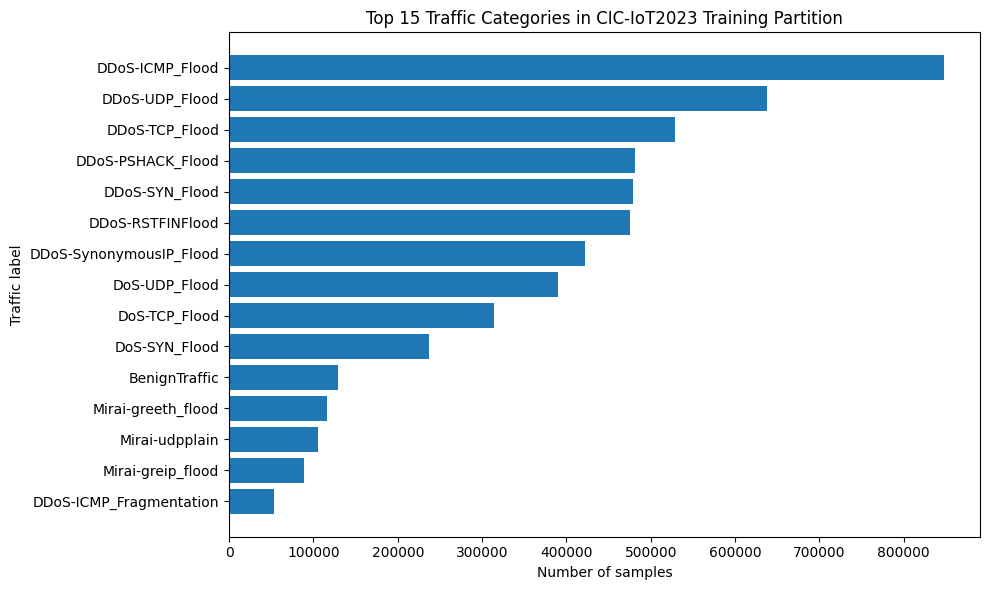

In [8]:
# Plot top 15 labels
top_n = 15
plt.figure(figsize=(10, 6))
plt.barh(label_df.head(top_n)["label"][::-1], label_df.head(top_n)["count"][::-1])
plt.xlabel("Number of samples")
plt.ylabel("Traffic label")
plt.title("Top 15 Traffic Categories in CIC-IoT2023 Training Partition")
plt.tight_layout()
plt.show()


5. Baseline experiment, Normal Random Split

In [9]:
# This experiment samples from the dataset and uses a standard stratified train/test split.  
# It represents performance when attack types are not intentionally excluded from training.

def load_baseline_sample():
    parts = []
    count = 0

    # Use total_rows if already computed; otherwise use known value from previous run
    sampling_frac = BASELINE_SAMPLE_ROWS / total_rows

    for chunk in pd.read_csv(TRAIN_PATH, chunksize=CHUNKSIZE):
        chunk["y"] = chunk["label"].apply(make_binary_y)

        # Sample from each chunk to avoid loading full dataset
        sampled = chunk.sample(frac=sampling_frac, random_state=RANDOM_STATE)
        parts.append(sampled)
        count += len(sampled)

        if count >= BASELINE_SAMPLE_ROWS:
            break

    df = pd.concat(parts, ignore_index=True)

    # Exact cap if slightly above
    if len(df) > BASELINE_SAMPLE_ROWS:
        df = df.sample(n=BASELINE_SAMPLE_ROWS, random_state=RANDOM_STATE)

    return df

baseline_df = load_baseline_sample()
print("Baseline sample shape:", baseline_df.shape)
print(baseline_df["y"].value_counts())


Baseline sample shape: (399992, 48)
y
1    390642
0      9350
Name: count, dtype: int64


In [10]:
X_base, y_base = prepare_xy(baseline_df)

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_base,
    y_base,
    test_size=0.2,
    stratify=y_base,
    random_state=RANDOM_STATE
)

rf_baseline = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

rf_baseline.fit(X_train_b, y_train_b)
pred_b = rf_baseline.predict(X_test_b)

print("Baseline Confusion Matrix:")
print(confusion_matrix(y_test_b, pred_b))

print("\nBaseline Classification Report:")
print(classification_report(y_test_b, pred_b, digits=4))


Baseline Confusion Matrix:
[[ 1744   126]
 [  112 78017]]

Baseline Classification Report:
              precision    recall  f1-score   support

           0     0.9397    0.9326    0.9361      1870
           1     0.9984    0.9986    0.9985     78129

    accuracy                         0.9970     79999
   macro avg     0.9690    0.9656    0.9673     79999
weighted avg     0.9970    0.9970    0.9970     79999



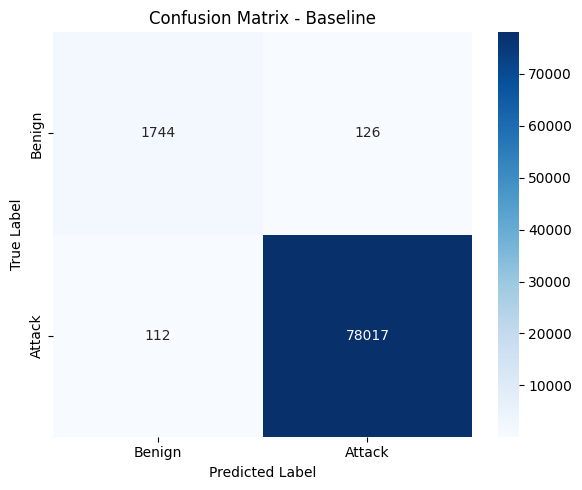

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = [[1744, 126],
      [112, 78017]]

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Attack'],
            yticklabels=['Benign', 'Attack'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Baseline')
plt.tight_layout()

plt.savefig('cm_baseline.png', dpi=300)
plt.show()

6.Zero-Day Experiment: Attack-Disjoint Split

In [12]:
# The zero-day attack categories are excluded from training.  
# The test set contains these unseen attack categories plus benign traffic.

def load_zero_day_split():
    train_parts = []
    test_parts = []
    train_count = 0
    test_count = 0

    for chunk in pd.read_csv(TRAIN_PATH, chunksize=CHUNKSIZE):
        chunk["y"] = chunk["label"].apply(make_binary_y)

        is_zero_day = chunk["label"].isin(ZERO_DAY_ATTACKS)
        is_benign = chunk["label"].eq("BenignTraffic")

        # Train: seen attacks + benign
        train_chunk = chunk[~is_zero_day]

        # Test: zero-day attacks + benign
        test_chunk = chunk[is_zero_day | is_benign]

        if train_count < ZERO_DAY_TRAIN_ROWS:
            remaining = ZERO_DAY_TRAIN_ROWS - train_count
            add = train_chunk
            if len(add) > remaining:
                add = add.sample(n=remaining, random_state=RANDOM_STATE)
            train_parts.append(add)
            train_count += len(add)

        if test_count < ZERO_DAY_TEST_ROWS:
            remaining = ZERO_DAY_TEST_ROWS - test_count
            add = test_chunk
            if len(add) > remaining:
                add = add.sample(n=remaining, random_state=RANDOM_STATE)
            test_parts.append(add)
            test_count += len(add)

        if train_count >= ZERO_DAY_TRAIN_ROWS and test_count >= ZERO_DAY_TEST_ROWS:
            break

    train_df = pd.concat(train_parts, ignore_index=True)
    test_df = pd.concat(test_parts, ignore_index=True)

    return train_df, test_df

train_df, test_df = load_zero_day_split()

print("Zero-day training shape:", train_df.shape)
print("Zero-day test shape:", test_df.shape)

print("\nTraining labels:")
print(train_df["y"].value_counts())

print("\nTest labels:")
print(test_df["y"].value_counts())

print("\nZero-day labels in test:")
print(test_df[test_df["label"].isin(ZERO_DAY_ATTACKS)]["label"].value_counts())


Zero-day training shape: (400000, 48)
Zero-day test shape: (133900, 48)

Training labels:
y
1    390694
0      9306
Name: count, dtype: int64

Test labels:
y
0    129538
1      4362
Name: count, dtype: int64

Zero-day labels in test:
label
DictionaryBruteForce    1541
BrowserHijacking         665
CommandInjection         620
SqlInjection             590
XSS                      414
Backdoor_Malware         392
Uploading_Attack         140
Name: count, dtype: int64


In [13]:
X_train_z, y_train_z = prepare_xy(train_df)
X_test_z, y_test_z = prepare_xy(test_df)

rf_zero_day = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

rf_zero_day.fit(X_train_z, y_train_z)

import joblib

# Save the trained zero-day model
joblib.dump(rf_zero_day, "rf_model.pkl")

# Save feature column order
joblib.dump(X_train_z.columns, "feature_columns.pkl")

print("Zero-day model saved successfully!")

pred_z = rf_zero_day.predict(X_test_z)
pred_z = rf_zero_day.predict(X_test_z)

print("Zero-Day Confusion Matrix:")
print(confusion_matrix(y_test_z, pred_z))

print("\nZero-Day Classification Report:")
print(classification_report(y_test_z, pred_z, digits=4))


Zero-day model saved successfully!
Zero-Day Confusion Matrix:
[[123084   6454]
 [   434   3928]]

Zero-Day Classification Report:
              precision    recall  f1-score   support

           0     0.9965    0.9502    0.9728    129538
           1     0.3783    0.9005    0.5328      4362

    accuracy                         0.9486    133900
   macro avg     0.6874    0.9253    0.7528    133900
weighted avg     0.9763    0.9486    0.9584    133900



7.Result table

In [14]:
def metrics_dict(name, y_true, y_pred):
    return {
        "Experiment": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Attack Precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Attack Recall": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "Attack F1": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
    }

results = pd.DataFrame([
    metrics_dict("Baseline normal split", y_test_b, pred_b),
    metrics_dict("Zero-day attack-disjoint", y_test_z, pred_z),
])

results


,Experiment,Accuracy,Attack Precision,Attack Recall,Attack F1
0,Baseline normal split,0.997025,0.998388,0.998566,0.998477
1,Zero-day attack-disjoint,0.948559,0.378347,0.900504,0.532827


In [15]:
results.to_csv("results_summary.csv", index=False)
print("Saved results_summary.csv")


Saved results_summary.csv


8.SHAP Explainability

In [16]:
# SHAP is computed on a small subset because explaining thousands or millions of samples is slow. 

# Use a small sample for SHAP
X_shap = X_test_z.sample(n=min(1000, len(X_test_z)), random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(rf_zero_day)
raw_shap_values = explainer.shap_values(X_shap)

# Convert SHAP output to a 2D matrix for attack class explanation
if isinstance(raw_shap_values, list):
    # Older SHAP versions: list[class0, class1]
    shap_values_attack = raw_shap_values[1]
else:
    raw_shap_values = np.array(raw_shap_values)
    if raw_shap_values.ndim == 3:
        # Newer SHAP versions may return (samples, features, classes)
        shap_values_attack = raw_shap_values[:, :, 1]
    elif raw_shap_values.ndim == 2:
        # Already samples x features
        shap_values_attack = raw_shap_values
    else:
        raise ValueError(f"Unexpected SHAP shape: {raw_shap_values.shape}")

print("X_shap shape:", X_shap.shape)
print("SHAP values shape:", shap_values_attack.shape)


X_shap shape: (1000, 46)
SHAP values shape: (1000, 46)


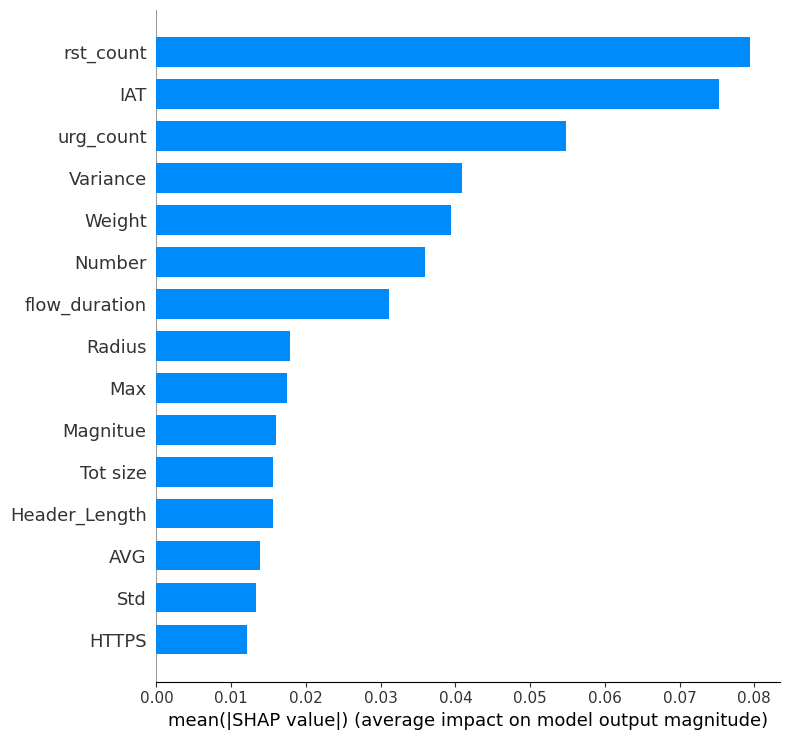

In [17]:
# SHAP bar plot: global feature importance
shap.summary_plot(
    shap_values_attack,
    X_shap,
    plot_type="bar",
    max_display=15
)


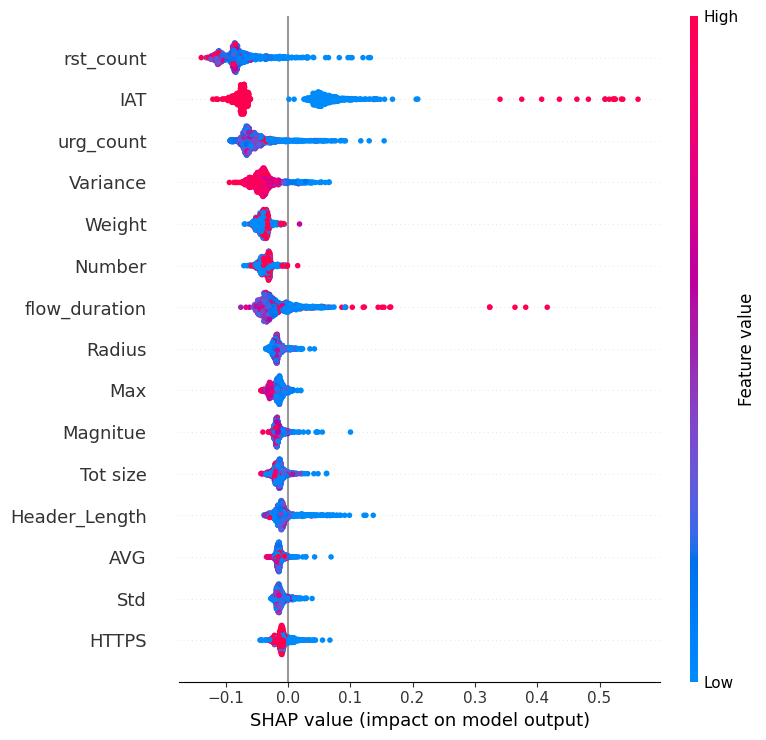

In [18]:
# SHAP beeswarm plot: direction and impact of features
shap.summary_plot(
    shap_values_attack,
    X_shap,
    max_display=15
)


In [19]:
# Print top 10 SHAP features as a table
mean_abs_shap = np.abs(shap_values_attack).mean(axis=0)
top_idx = np.argsort(mean_abs_shap)[::-1][:10]

shap_importance = pd.DataFrame({
    "feature": X_shap.columns[top_idx],
    "mean_abs_shap": mean_abs_shap[top_idx]
})

shap_importance


,feature,mean_abs_shap
0,rst_count,0.079466
1,IAT,0.075317
2,urg_count,0.054822
3,Variance,0.040907
4,Weight,0.039446
5,Number,0.035896
6,flow_duration,0.031087
7,Radius,0.017819
8,Max,0.017507
9,Magnitue,0.015990


In [20]:
shap_importance.to_csv("shap_feature_importance.csv", index=False)
print("Saved shap_feature_importance.csv")


Saved shap_feature_importance.csv


9. XGBoost 

In [21]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt

print("Loading data...")

# ── Load data the same way your notebook does ──────────────────────
TRAIN_PATH = r"train\train.csv"
CHUNKSIZE = 250_000
SAMPLE_ROWS = 400_000

chunks = []
total = 0
for chunk in pd.read_csv(TRAIN_PATH, chunksize=CHUNKSIZE):
    chunks.append(chunk)
    total += len(chunk)
    if total >= SAMPLE_ROWS:
        break

df = pd.concat(chunks, ignore_index=True).head(SAMPLE_ROWS)
print(f"Loaded {len(df)} rows")

# ── Prepare features and labels ────────────────────────────────────
df["y"] = df["label"].apply(lambda x: 0 if x == "BenignTraffic" else 1)
X = df.drop(columns=["label", "y"], errors="ignore")
X = X.apply(pd.to_numeric, errors="coerce").fillna(0)
y = df["y"].astype(int)

# ── Train/test split ───────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Attack ratio in train: {y_train.mean():.2%}")

# ── Train XGBoost ──────────────────────────────────────────────────
print("\nTraining XGBoost...")
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)
print("Training done!")

# ── Evaluate ───────────────────────────────────────────────────────
xgb_preds = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

print("\n=== XGBoost Baseline Results ===")
print(classification_report(y_test, xgb_preds, target_names=["Benign", "Attack"]))
print("AUC-ROC:", round(roc_auc_score(y_test, xgb_proba), 4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, xgb_preds))

Loading data...
Loaded 400000 rows
Train: 320000 | Test: 80000
Attack ratio in train: 97.68%

Training XGBoost...
Training done!

=== XGBoost Baseline Results ===
              precision    recall  f1-score   support

      Benign       0.77      1.00      0.87      1857
      Attack       1.00      0.99      1.00     78143

    accuracy                           0.99     80000
   macro avg       0.89      1.00      0.93     80000
weighted avg       0.99      0.99      0.99     80000

AUC-ROC: 0.9993

Confusion Matrix:
[[ 1853     4]
 [  553 77590]]


In [22]:
print("Loading data for attack-disjoint XGBoost...")

ZERO_DAY_ATTACKS = {
    "SqlInjection", "XSS", "CommandInjection",
    "BrowserHijacking", "Uploading_Attack",
    "Backdoor_Malware", "DictionaryBruteForce"
}

# ── Load data ──────────────────────────────────────────────────────
chunks = []
total = 0
for chunk in pd.read_csv(TRAIN_PATH, chunksize=CHUNKSIZE):
    chunks.append(chunk)
    total += len(chunk)
    if total >= 600_000:
        break

df2 = pd.concat(chunks, ignore_index=True).head(600_000)
df2["y"] = df2["label"].apply(lambda x: 0 if x == "BenignTraffic" else 1)

# ── Split: remove attack-disjoint attacks from training ───────────
train_df = df2[~df2["label"].isin(ZERO_DAY_ATTACKS)].head(400_000)
test_df  = df2[df2["label"].isin(ZERO_DAY_ATTACKS) | 
               (df2["label"] == "BenignTraffic")].head(200_000)

print(f"Train rows: {len(train_df)} | Test rows: {len(test_df)}")
print(f"Withheld attacks in test: {test_df[test_df['y']==1]['label'].nunique()} types")

# ── Prepare X, y ───────────────────────────────────────────────────
def prep(df):
    X = df.drop(columns=["label","y"], errors="ignore")
    X = X.apply(pd.to_numeric, errors="coerce").fillna(0)
    return X, df["y"].astype(int)

X_tr, y_tr = prep(train_df)
X_te, y_te = prep(test_df)

# ── Train XGBoost ──────────────────────────────────────────────────
print("\nTraining XGBoost (attack-disjoint)...")
xgb_zd = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=len(y_tr[y_tr==0]) / len(y_tr[y_tr==1]),
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb_zd.fit(X_tr, y_tr)

# ── Evaluate ───────────────────────────────────────────────────────
preds = xgb_zd.predict(X_te)
proba = xgb_zd.predict_proba(X_te)[:, 1]

print("\n=== XGBoost Attack-Disjoint Results ===")
print(classification_report(y_te, preds, target_names=["Benign","Attack"]))
print("AUC-ROC:", round(roc_auc_score(y_te, proba), 4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_te, preds))

Loading data for attack-disjoint XGBoost...
Train rows: 400000 | Test rows: 14394
Withheld attacks in test: 7 types

Training XGBoost (attack-disjoint)...

=== XGBoost Attack-Disjoint Results ===
              precision    recall  f1-score   support

      Benign       0.98      1.00      0.99     13906
      Attack       0.95      0.34      0.50       488

    accuracy                           0.98     14394
   macro avg       0.96      0.67      0.74     14394
weighted avg       0.98      0.98      0.97     14394

AUC-ROC: 0.9669

Confusion Matrix:
[[13897     9]
 [  322   166]]


In [23]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Loading data for Isolation Forest...")

# Load data
chunks = []
total = 0
for chunk in pd.read_csv(TRAIN_PATH, chunksize=CHUNKSIZE):
    chunks.append(chunk)
    total += len(chunk)
    if total >= 600_000:
        break

df3 = pd.concat(chunks, ignore_index=True).head(600_000)
df3["y"] = df3["label"].apply(lambda x: 0 if x == "BenignTraffic" else 1)

# Train ONLY on benign samples
benign_train = df3[df3["label"] == "BenignTraffic"].head(50_000)
X_benign = benign_train.drop(columns=["label","y"], errors="ignore")
X_benign = X_benign.apply(pd.to_numeric, errors="coerce").fillna(0)

# Test on withheld attacks + benign
ZERO_DAY_ATTACKS = {
    "SqlInjection", "XSS", "CommandInjection",
    "BrowserHijacking", "Uploading_Attack",
    "Backdoor_Malware", "DictionaryBruteForce"
}
test_df3 = df3[df3["label"].isin(ZERO_DAY_ATTACKS) |
               (df3["label"] == "BenignTraffic")].head(200_000)
X_te3 = test_df3.drop(columns=["label","y"], errors="ignore")
X_te3 = X_te3.apply(pd.to_numeric, errors="coerce").fillna(0)
y_te3 = test_df3["y"].astype(int)

print(f"Training on {len(X_benign)} benign samples only")
print(f"Testing on {len(X_te3)} samples ({y_te3.sum()} attacks)")

# Train Isolation Forest
print("\nTraining Isolation Forest...")
iso = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)
iso.fit(X_benign)

# Predict: Isolation Forest returns -1 for anomaly, 1 for normal
# Convert to: 1 = attack, 0 = benign
raw_preds = iso.predict(X_te3)
iso_preds = np.where(raw_preds == -1, 1, 0)
iso_scores = -iso.score_samples(X_te3)  # higher = more anomalous

print("\n=== Isolation Forest Attack-Disjoint Results ===")
print(classification_report(y_te3, iso_preds, target_names=["Benign","Attack"]))
print("AUC-ROC:", round(roc_auc_score(y_te3, iso_scores), 4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_te3, iso_preds))

Loading data for Isolation Forest...
Training on 13906 benign samples only
Testing on 14394 samples (488 attacks)

Training Isolation Forest...

=== Isolation Forest Attack-Disjoint Results ===
              precision    recall  f1-score   support

      Benign       0.97      0.95      0.96     13906
      Attack       0.05      0.07      0.06       488

    accuracy                           0.92     14394
   macro avg       0.51      0.51      0.51     14394
weighted avg       0.94      0.92      0.93     14394

AUC-ROC: 0.6344

Confusion Matrix:
[[13210   696]
 [  454    34]]


In [24]:
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler

print("Loading data for One-Class SVM...")

# Reuse the same test set from Isolation Forest (X_te3, y_te3)
# Just need to retrain on benign samples with scaling

# Scale the data (required for SVM)
scaler = StandardScaler()
X_benign_scaled = scaler.fit_transform(X_benign)
X_te3_scaled = scaler.transform(X_te3)

print(f"Training on {len(X_benign_scaled)} benign samples only")

# Train One-Class SVM
# Note: nu is the upper bound on the fraction of outliers
print("Training One-Class SVM (this may take 2-3 minutes)...")
oc_svm = OneClassSVM(
    kernel='rbf',
    nu=0.05,
    gamma='scale'
)
oc_svm.fit(X_benign_scaled)

# Predict: returns -1 for anomaly, 1 for normal
raw_preds_svm = oc_svm.predict(X_te3_scaled)
svm_preds = np.where(raw_preds_svm == -1, 1, 0)
svm_scores = -oc_svm.score_samples(X_te3_scaled)

print("\n=== One-Class SVM Attack-Disjoint Results ===")
print(classification_report(y_te3, svm_preds, target_names=["Benign","Attack"]))
print("AUC-ROC:", round(roc_auc_score(y_te3, svm_scores), 4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_te3, svm_preds))

Loading data for One-Class SVM...
Training on 13906 benign samples only
Training One-Class SVM (this may take 2-3 minutes)...

=== One-Class SVM Attack-Disjoint Results ===
              precision    recall  f1-score   support

      Benign       0.97      0.95      0.96     13906
      Attack       0.17      0.29      0.21       488

    accuracy                           0.93     14394
   macro avg       0.57      0.62      0.59     14394
weighted avg       0.95      0.93      0.94     14394

AUC-ROC: 0.7402

Confusion Matrix:
[[13208   698]
 [  347   141]]


In [25]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("Checking TensorFlow...")
print("TF version:", tf.__version__)

# ── Prepare data (reuse X_benign and X_te3 from before) ───────────
scaler2 = StandardScaler()
X_benign_sc = scaler2.fit_transform(X_benign)
X_te3_sc    = scaler2.transform(X_te3)

input_dim = X_benign_sc.shape[1]
print(f"Input features: {input_dim}")

# ── Build Autoencoder ──────────────────────────────────────────────
encoder = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
])

decoder = keras.Sequential([
    layers.Input(shape=(16,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(input_dim, activation='linear'),
])

autoencoder = keras.Sequential([encoder, decoder])
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

# ── Train on benign only ───────────────────────────────────────────
print("\nTraining Autoencoder...")
autoencoder.fit(
    X_benign_sc, X_benign_sc,
    epochs=20,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

# ── Get reconstruction error ───────────────────────────────────────
reconstructed = autoencoder.predict(X_te3_sc)
reconstruction_error = np.mean(np.power(X_te3_sc - reconstructed, 2), axis=1)

# ── Set threshold at 95th percentile of benign training errors ─────
benign_recon = autoencoder.predict(X_benign_sc)
benign_errors = np.mean(np.power(X_benign_sc - benign_recon, 2), axis=1)
threshold = np.percentile(benign_errors, 95)
print(f"\nReconstruction error threshold: {threshold:.6f}")

# ── Classify ───────────────────────────────────────────────────────
ae_preds = (reconstruction_error > threshold).astype(int)

print("\n=== Autoencoder Attack-Disjoint Results ===")
print(classification_report(y_te3, ae_preds, target_names=["Benign","Attack"]))
print("AUC-ROC:", round(roc_auc_score(y_te3, reconstruction_error), 4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_te3, ae_preds))

Checking TensorFlow...
TF version: 2.21.0
Input features: 46


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 16)             │         5,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 46)             │         5,646 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,262 (43.99 KB)

 Trainable params: 11,262 (43.99 KB)

 Non-trainable params: 0 (0.00 B)


Training Autoencoder...
Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6732 - val_loss: 0.6014
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4076 - val_loss: 0.4425
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2895 - val_loss: 0.3817
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2285 - val_loss: 0.3521
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1795 - val_loss: 0.3302
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1441 - val_loss: 0.3111
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1226 - val_loss: 0.3038
Epoch 8/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1122 - val_loss: 0.2932
Epoch 9/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0974 - val_loss: 0.2835
Epoch 10/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0816 - val_loss: 0.2793
Epoch 11/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0738 - val_loss: 0.2723
Epoch 12/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/ste

In [27]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve
import joblib

print("Loading saved RF model and data for threshold tuning...")

# ── Reload your original RF model and test data ────────────────────
rf = joblib.load("rf_model.pkl")
feature_columns = joblib.load("feature_columns.pkl")

# Load the final test dataset
test_df_final = pd.read_csv(r"test\test.csv")
test_df_final["y"] = test_df_final["label"].apply(
    lambda x: 0 if x == "BenignTraffic" else 1
)
X_final = test_df_final.drop(columns=["label","y"], errors="ignore")
X_final = X_final.apply(pd.to_numeric, errors="coerce").fillna(0)
X_final = X_final.reindex(columns=feature_columns, fill_value=0)
y_final = test_df_final["y"].astype(int)

print(f"Test samples: {len(y_final)} | Attacks: {y_final.sum()}")

# ── Get probabilities ──────────────────────────────────────────────
proba_final = rf.predict_proba(X_final)[:, 1]

# ── Test different thresholds ──────────────────────────────────────
print("\n=== Threshold Tuning Results ===")
print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print("-" * 48)

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
for t in thresholds:
    preds_t = (proba_final >= t).astype(int)
    from sklearn.metrics import precision_score, recall_score, f1_score
    p = precision_score(y_final, preds_t, zero_division=0)
    r = recall_score(y_final, preds_t, zero_division=0)
    f = f1_score(y_final, preds_t, zero_division=0)
    print(f"{t:<12} {p:<12.4f} {r:<12.4f} {f:<12.4f}")

# ── Cost-sensitive learning ────────────────────────────────────────
print("\n=== Cost-Sensitive Learning Results ===")

# Reload training data
chunks_cs = []
total_cs = 0
for chunk in pd.read_csv(TRAIN_PATH, chunksize=CHUNKSIZE):
    chunks_cs.append(chunk)
    total_cs += len(chunk)
    if total_cs >= 400_000:
        break

df_cs = pd.concat(chunks_cs, ignore_index=True).head(400_000)
df_cs["y"] = df_cs["label"].apply(lambda x: 0 if x == "BenignTraffic" else 1)
X_cs = df_cs.drop(columns=["label","y"], errors="ignore")
X_cs = X_cs.apply(pd.to_numeric, errors="coerce").fillna(0)
y_cs = df_cs["y"].astype(int)

X_tr_cs, X_te_cs, y_tr_cs, y_te_cs = train_test_split(
    X_cs, y_cs, test_size=0.2, random_state=42, stratify=y_cs
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

print(f"\n{'Cost Ratio':<15} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print("-" * 51)

for ratio in [1, 5, 10]:
    rf_cost = RandomForestClassifier(
        n_estimators=100,
        class_weight={0: 1, 1: ratio},
        random_state=42,
        n_jobs=-1
    )
    rf_cost.fit(X_tr_cs, y_tr_cs)
    preds_cost = rf_cost.predict(X_te_cs)
    p = precision_score(y_te_cs, preds_cost, zero_division=0)
    r = recall_score(y_te_cs, preds_cost, zero_division=0)
    f = f1_score(y_te_cs, preds_cost, zero_division=0)
    print(f"1:{ratio:<14} {p:<12.4f} {r:<12.4f} {f:<12.4f}")

Loading saved RF model and data for threshold tuning...
Test samples: 1176851 | Attacks: 1149142

=== Threshold Tuning Results ===
Threshold    Precision    Recall       F1          
------------------------------------------------
0.3          0.9968       0.9991       0.9979      
0.4          0.9979       0.9987       0.9983      
0.5          0.9986       0.9982       0.9984      
0.6          0.9992       0.9976       0.9984      
0.7          0.9996       0.9969       0.9982      
0.8          0.9998       0.9959       0.9978      

=== Cost-Sensitive Learning Results ===

Cost Ratio      Precision    Recall       F1          
---------------------------------------------------
1:1              0.9988       0.9981       0.9985      
1:5              0.9988       0.9979       0.9984      
1:10             0.9989       0.9978       0.9983      


In [28]:
print("Threshold tuning on attack-disjoint test set...")

# Rebuild attack-disjoint split
ZERO_DAY_ATTACKS = {
    "SqlInjection", "XSS", "CommandInjection",
    "BrowserHijacking", "Uploading_Attack",
    "Backdoor_Malware", "DictionaryBruteForce"
}

chunks = []
total = 0
for chunk in pd.read_csv(TRAIN_PATH, chunksize=CHUNKSIZE):
    chunks.append(chunk)
    total += len(chunk)
    if total >= 600_000:
        break

df_th = pd.concat(chunks, ignore_index=True).head(600_000)
df_th["y"] = df_th["label"].apply(lambda x: 0 if x == "BenignTraffic" else 1)

# Training set - no withheld attacks
train_th = df_th[~df_th["label"].isin(ZERO_DAY_ATTACKS)].head(400_000)

# Test set - only withheld attacks + benign
test_th = df_th[
    df_th["label"].isin(ZERO_DAY_ATTACKS) |
    (df_th["label"] == "BenignTraffic")
].head(200_000)

def prep(df):
    X = df.drop(columns=["label","y"], errors="ignore")
    X = X.apply(pd.to_numeric, errors="coerce").fillna(0)
    return X, df["y"].astype(int)

X_tr_th, y_tr_th = prep(train_th)
X_te_th, y_te_th = prep(test_th)

print(f"Train: {len(X_tr_th)} | Test: {len(X_te_th)}")
print(f"Attacks in test: {y_te_th.sum()} ({y_te_th.mean():.2%})")

# Train RF
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

print("\nTraining RF for threshold experiment...")
rf_th = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_th.fit(X_tr_th, y_tr_th)
proba_th = rf_th.predict_proba(X_te_th)[:, 1]

# Threshold tuning
print("\n=== Threshold Tuning (Attack-Disjoint) ===")
print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print("-" * 48)
for t in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    preds_t = (proba_th >= t).astype(int)
    p = precision_score(y_te_th, preds_t, zero_division=0)
    r = recall_score(y_te_th, preds_t, zero_division=0)
    f = f1_score(y_te_th, preds_t, zero_division=0)
    print(f"{t:<12} {p:<12.4f} {r:<12.4f} {f:<12.4f}")

# Cost-sensitive learning
print("\n=== Cost-Sensitive Learning (Attack-Disjoint) ===")
print(f"{'Cost Ratio':<15} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print("-" * 51)
for ratio in [1, 5, 10]:
    rf_c = RandomForestClassifier(
        n_estimators=100,
        class_weight={0: 1, 1: ratio},
        random_state=42,
        n_jobs=-1
    )
    rf_c.fit(X_tr_th, y_tr_th)
    preds_c = rf_c.predict(X_te_th)
    p = precision_score(y_te_th, preds_c, zero_division=0)
    r = recall_score(y_te_th, preds_c, zero_division=0)
    f = f1_score(y_te_th, preds_c, zero_division=0)
    print(f"1:{ratio:<14} {p:<12.4f} {r:<12.4f} {f:<12.4f}")

Threshold tuning on attack-disjoint test set...
Train: 400000 | Test: 14394
Attacks in test: 488 (3.39%)

Training RF for threshold experiment...

=== Threshold Tuning (Attack-Disjoint) ===
Threshold    Precision    Recall       F1          
------------------------------------------------
0.3          0.4010       0.9795       0.5690      
0.4          0.5261       0.9508       0.6774      
0.5          0.6234       0.8750       0.7280      
0.6          0.6894       0.8094       0.7446      
0.7          0.7838       0.7357       0.7590      
0.8          0.8938       0.6209       0.7328      

=== Cost-Sensitive Learning (Attack-Disjoint) ===
Cost Ratio      Precision    Recall       F1          
---------------------------------------------------
1:1              0.6667       0.8689       0.7544      
1:5              0.6835       0.8320       0.7505      
1:10             0.6917       0.8504       0.7629      


In [29]:
print("Running Ablation Study...")

# Reuse X_tr_th, y_tr_th, X_te_th, y_te_th from previous cell
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score

print(f"\n{'Configuration':<40} {'Precision':<12} {'Recall':<12} {'F1':<12} {'AUC':<10}")
print("-" * 74)

configs = [
    ("RF full (200 trees, balanced)",
     RandomForestClassifier(n_estimators=200, class_weight='balanced',
                            random_state=42, n_jobs=-1)),
    ("RF no class balancing",
     RandomForestClassifier(n_estimators=200,
                            random_state=42, n_jobs=-1)),
    ("RF 100 trees balanced",
     RandomForestClassifier(n_estimators=100, class_weight='balanced',
                            random_state=42, n_jobs=-1)),
    ("RF 50 trees balanced",
     RandomForestClassifier(n_estimators=50, class_weight='balanced',
                            random_state=42, n_jobs=-1)),
    ("RF 10 trees balanced",
     RandomForestClassifier(n_estimators=10, class_weight='balanced',
                            random_state=42, n_jobs=-1)),
]

results_ablation = []
for name, model in configs:
    model.fit(X_tr_th, y_tr_th)
    preds = model.predict(X_te_th)
    proba = model.predict_proba(X_te_th)[:, 1]
    p = precision_score(y_te_th, preds, zero_division=0)
    r = recall_score(y_te_th, preds, zero_division=0)
    f = f1_score(y_te_th, preds, zero_division=0)
    auc = roc_auc_score(y_te_th, proba)
    results_ablation.append((name, p, r, f, auc))
    print(f"{name:<40} {p:<12.4f} {r:<12.4f} {f:<12.4f} {auc:<10.4f}")

# Now test SHAP-based feature selection
print("\nRunning SHAP feature selection ablation...")
import shap
import numpy as np

# Get SHAP values from full model
rf_full = configs[0][1]  # already trained
explainer = shap.TreeExplainer(rf_full)
shap_sample = X_te_th.iloc[:500]
shap_values = explainer.shap_values(shap_sample)

# Handle both old and new SHAP output formats
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values[:, :, 1] if shap_values.ndim == 3 else shap_values

mean_shap = np.abs(sv).mean(axis=0)
top_features = X_te_th.columns[np.argsort(mean_shap)[::-1]]

print(f"\nTop 10 features by SHAP: {list(top_features[:10])}")

for k in [10, 20]:
    top_k = list(top_features[:k])
    rf_shap = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                     random_state=42, n_jobs=-1)
    rf_shap.fit(X_tr_th[top_k], y_tr_th)
    preds_s = rf_shap.predict(X_te_th[top_k])
    proba_s = rf_shap.predict_proba(X_te_th[top_k])[:, 1]
    p = precision_score(y_te_th, preds_s, zero_division=0)
    r = recall_score(y_te_th, preds_s, zero_division=0)
    f = f1_score(y_te_th, preds_s, zero_division=0)
    auc = roc_auc_score(y_te_th, proba_s)
    print(f"{'RF top-'+str(k)+' SHAP features':<40} {p:<12.4f} {r:<12.4f} {f:<12.4f} {auc:<10.4f}")

Running Ablation Study...

Configuration                            Precision    Recall       F1           AUC       
--------------------------------------------------------------------------
RF full (200 trees, balanced)            0.6338       0.8689       0.7329       0.9921    
RF no class balancing                    0.6719       0.8811       0.7624       0.9928    
RF 100 trees balanced                    0.6313       0.8668       0.7306       0.9919    
RF 50 trees balanced                     0.6257       0.8566       0.7232       0.9910    
RF 10 trees balanced                     0.6240       0.8402       0.7162       0.9841    

Running SHAP feature selection ablation...

Top 10 features by SHAP: ['rst_count', 'IAT', 'urg_count', 'Variance', 'Number', 'Weight', 'flow_duration', 'Radius', 'Header_Length', 'AVG']
RF top-10 SHAP features                  0.6161       0.8648       0.7195       0.9914    
RF top-20 SHAP features                  0.6328       0.8545       0.7271 

In [30]:
print("Installing LIME...")
import sys
!{sys.executable} -m pip install lime -q

import lime
import lime.lime_tabular
import numpy as np
import time
import shap
from sklearn.metrics import r2_score

print("Setting up SHAP and LIME comparison...")

# Use RF full model and test data from ablation
# Take a small sample for comparison
sample_idx = np.random.choice(len(X_te_th), 200, replace=False)
X_sample = X_te_th.iloc[sample_idx]
y_sample = y_te_th.iloc[sample_idx]

rf_full_model = configs[0][1]  # RF full already trained

# ── SHAP on 200 samples ────────────────────────────────────────────
print("\nRunning SHAP on 200 samples...")
start = time.time()
explainer_shap = shap.TreeExplainer(rf_full_model)
shap_vals = explainer_shap.shap_values(X_sample)
if isinstance(shap_vals, list):
    sv = shap_vals[1]
else:
    sv = shap_vals[:, :, 1] if shap_vals.ndim == 3 else shap_vals
shap_time = time.time() - start
print(f"SHAP time for 200 samples: {shap_time:.2f}s")

# SHAP top 5 features
mean_shap_vals = np.abs(sv).mean(axis=0)
shap_ranking = X_sample.columns[np.argsort(mean_shap_vals)[::-1]]
top5_shap = list(shap_ranking[:5])
print(f"SHAP Top 5 features: {top5_shap}")

# ── LIME on 200 samples ────────────────────────────────────────────
print("\nRunning LIME on 200 samples (this takes ~2 minutes)...")
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_tr_th.values,
    feature_names=X_tr_th.columns.tolist(),
    class_names=["Benign", "Attack"],
    mode="classification"
)

start = time.time()
lime_importances = np.zeros((len(X_sample), X_sample.shape[1]))
feature_names = X_sample.columns.tolist()

for i in range(len(X_sample)):
    exp = lime_explainer.explain_instance(
        X_sample.iloc[i].values,
        rf_full_model.predict_proba,
        num_features=10
    )
    for feat, val in exp.as_list():
        # Match feature name
        for j, fname in enumerate(feature_names):
            if fname in feat:
                lime_importances[i, j] += abs(val)
                break

lime_time = time.time() - start
print(f"LIME time for 200 samples: {lime_time:.2f}s")

# LIME top 5 features
mean_lime_vals = lime_importances.mean(axis=0)
lime_ranking = X_sample.columns[np.argsort(mean_lime_vals)[::-1]]
top5_lime = list(lime_ranking[:5])
print(f"LIME Top 5 features: {top5_lime}")

# ── Comparison ─────────────────────────────────────────────────────
print("\n=== SHAP vs LIME Comparison ===")
print(f"SHAP computation time (200 samples): {shap_time:.2f}s")
print(f"LIME computation time (200 samples): {lime_time:.2f}s")
print(f"Speed difference: LIME is {lime_time/shap_time:.1f}x slower than SHAP")
print(f"\nSHAP Top 5 features: {top5_shap}")
print(f"LIME Top 5 features: {top5_lime}")

overlap = len(set(top5_shap) & set(top5_lime))
print(f"\nTop-5 feature agreement: {overlap}/5 ({overlap*20}%)")

# RF built-in feature importance for reference
rf_builtin = X_sample.columns[np.argsort(
    rf_full_model.feature_importances_)[::-1]]
top5_builtin = list(rf_builtin[:5])
print(f"RF built-in Top 5: {top5_builtin}")
shap_agree = len(set(top5_shap) & set(top5_builtin))
lime_agree = len(set(top5_lime) & set(top5_builtin))
print(f"\nSHAP agreement with RF built-in: {shap_agree}/5 ({shap_agree*20}%)")
print(f"LIME agreement with RF built-in: {lime_agree}/5 ({lime_agree*20}%)")

Installing LIME...



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Setting up SHAP and LIME comparison...

Running SHAP on 200 samples...
SHAP time for 200 samples: 52.12s
SHAP Top 5 features: ['rst_count', 'IAT', 'urg_count', 'Variance', 'Weight']

Running LIME on 200 samples (this takes ~2 minutes)...


c:\Users\danje\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\danje\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\danje\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\danje\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\danje\AppData\Local\Programs\Python\Python312\Lib\site-packages\skl

LIME time for 200 samples: 18.16s
LIME Top 5 features: ['Number', 'Weight', 'rst_count', 'urg_count', 'Magnitue']

=== SHAP vs LIME Comparison ===
SHAP computation time (200 samples): 52.12s
LIME computation time (200 samples): 18.16s
Speed difference: LIME is 0.3x slower than SHAP

SHAP Top 5 features: ['rst_count', 'IAT', 'urg_count', 'Variance', 'Weight']
LIME Top 5 features: ['Number', 'Weight', 'rst_count', 'urg_count', 'Magnitue']

Top-5 feature agreement: 3/5 (60%)
RF built-in Top 5: ['rst_count', 'urg_count', 'Variance', 'Radius', 'Tot size']

SHAP agreement with RF built-in: 3/5 (60%)
LIME agreement with RF built-in: 2/5 (40%)


c:\Users\danje\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Running PCA and t-SNE analysis...
Running PCA...
PCA explained variance: PC1=22.57%, PC2=12.12%, Total=34.69%


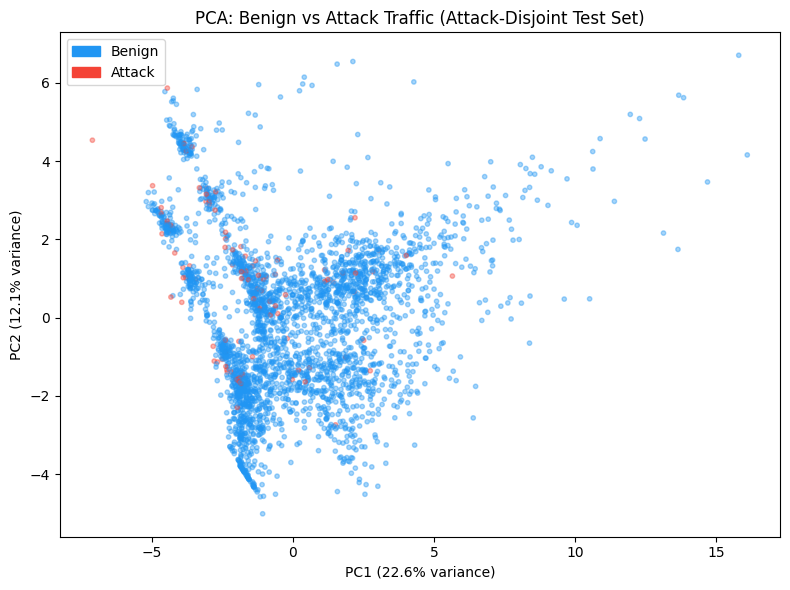

PCA plot saved as pca_plot.png

Running t-SNE (this takes 2-3 minutes)...


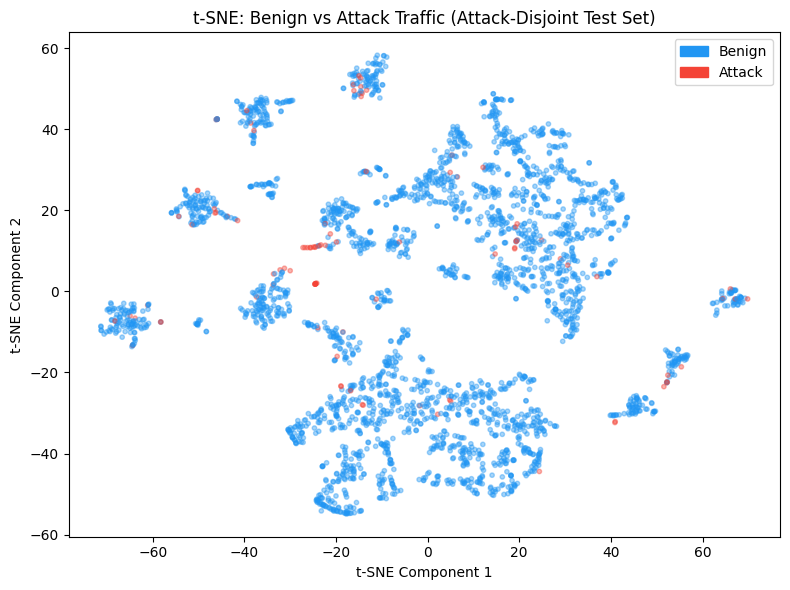

t-SNE plot saved as tsne_plot.png


In [31]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

print("Running PCA and t-SNE analysis...")

# Sample from attack-disjoint test data
sample_size = 3000
idx = np.random.choice(len(X_te_th), sample_size, replace=False)
X_vis = X_te_th.iloc[idx]
y_vis = y_te_th.iloc[idx]

# Scale
scaler_vis = StandardScaler()
X_vis_scaled = scaler_vis.fit_transform(X_vis)

# Colors and legend
colors = ['#2196F3' if y == 0 else '#F44336' for y in y_vis]
legend = [Patch(color='#2196F3', label='Benign'),
          Patch(color='#F44336', label='Attack')]

# ── PCA ────────────────────────────────────────────────────────────
print("Running PCA...")
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_vis_scaled)
explained = pca.explained_variance_ratio_
print(f"PCA explained variance: PC1={explained[0]:.2%}, PC2={explained[1]:.2%}, Total={sum(explained):.2%}")

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.4, s=10)
plt.xlabel(f'PC1 ({explained[0]:.1%} variance)')
plt.ylabel(f'PC2 ({explained[1]:.1%} variance)')
plt.title('PCA: Benign vs Attack Traffic (Attack-Disjoint Test Set)')
plt.legend(handles=legend)
plt.tight_layout()
plt.savefig('pca_plot.png', dpi=150)
plt.show()
print("PCA plot saved as pca_plot.png")

# ── t-SNE ──────────────────────────────────────────────────────────
print("\nRunning t-SNE (this takes 2-3 minutes)...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_vis_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors, alpha=0.4, s=10)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE: Benign vs Attack Traffic (Attack-Disjoint Test Set)')
plt.legend(handles=legend)
plt.tight_layout()
plt.savefig('tsne_plot.png', dpi=150)
plt.show()
print("t-SNE plot saved as tsne_plot.png")

In [32]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

print("Running per-attack-type analysis...")

# Reload data keeping original labels
chunks = []
total = 0
for chunk in pd.read_csv(TRAIN_PATH, chunksize=CHUNKSIZE):
    chunks.append(chunk)
    total += len(chunk)
    if total >= 600_000:
        break

df_atk = pd.concat(chunks, ignore_index=True).head(600_000)
df_atk["y"] = df_atk["label"].apply(lambda x: 0 if x == "BenignTraffic" else 1)

ZERO_DAY_ATTACKS = {
    "SqlInjection", "XSS", "CommandInjection",
    "BrowserHijacking", "Uploading_Attack",
    "Backdoor_Malware", "DictionaryBruteForce"
}

# Training set
train_atk = df_atk[~df_atk["label"].isin(ZERO_DAY_ATTACKS)].head(400_000)
X_tr_atk = train_atk.drop(columns=["label","y"], errors="ignore")
X_tr_atk = X_tr_atk.apply(pd.to_numeric, errors="coerce").fillna(0)
y_tr_atk = train_atk["y"].astype(int)

# Test set - keep labels for per-attack analysis
test_atk = df_atk[df_atk["label"].isin(ZERO_DAY_ATTACKS)].head(50_000)
X_te_atk = test_atk.drop(columns=["label","y"], errors="ignore")
X_te_atk = X_te_atk.apply(pd.to_numeric, errors="coerce").fillna(0)
y_te_atk = test_atk["y"].astype(int)

# Train RF
from sklearn.ensemble import RandomForestClassifier
rf_atk = RandomForestClassifier(
    n_estimators=100, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf_atk.fit(X_tr_atk, y_tr_atk)
all_preds = rf_atk.predict(X_te_atk)

# Per-attack-type results
print(f"\n{'Attack Type':<25} {'Samples':<10} {'Precision':<12} {'Recall':<12} {'F1':<10}")
print("-" * 69)

results_per_attack = []
for attack in sorted(ZERO_DAY_ATTACKS):
    mask = test_atk["label"] == attack
    if mask.sum() == 0:
        continue
    y_true_atk = y_te_atk[mask]
    y_pred_atk = pd.Series(all_preds, index=test_atk.index)[mask]
    r = recall_score(y_true_atk, y_pred_atk, zero_division=0)
    p = precision_score(y_true_atk, y_pred_atk, zero_division=0)
    f = f1_score(y_true_atk, y_pred_atk, zero_division=0)
    n = mask.sum()
    results_per_attack.append((attack, n, p, r, f))
    print(f"{attack:<25} {n:<10} {p:<12.4f} {r:<12.4f} {f:<10.4f}")

# Sort by recall to show difficulty ranking
print("\n=== Difficulty Ranking (easiest to hardest by Recall) ===")
ranked = sorted(results_per_attack, key=lambda x: x[3], reverse=True)
for i, (atk, n, p, r, f) in enumerate(ranked, 1):
    print(f"Rank {i}: {atk:<25} Recall={r:.4f}")

Running per-attack-type analysis...

Attack Type               Samples    Precision    Recall       F1        
---------------------------------------------------------------------
Backdoor_Malware          41         1.0000       1.0000       1.0000    
BrowserHijacking          72         1.0000       0.8194       0.9008    
CommandInjection          66         1.0000       0.9697       0.9846    
DictionaryBruteForce      164        1.0000       0.8598       0.9246    
SqlInjection              76         1.0000       0.7237       0.8397    
Uploading_Attack          21         1.0000       0.9048       0.9500    
XSS                       48         1.0000       0.9167       0.9565    

=== Difficulty Ranking (easiest to hardest by Recall) ===
Rank 1: Backdoor_Malware          Recall=1.0000
Rank 2: CommandInjection          Recall=0.9697
Rank 3: XSS                       Recall=0.9167
Rank 4: Uploading_Attack          Recall=0.9048
Rank 5: DictionaryBruteForce      Recall=0.8598
Ra

In [33]:
import time
import numpy as np

print("Running real-time feasibility analysis...")
print("Measuring inference time for each model...\n")

# Use X_te_th as test data
test_data = X_te_th.copy()

results_time = []

# ── Random Forest ──────────────────────────────────────────────────
times = []
for _ in range(5):
    start = time.time()
    rf_th.predict(test_data)
    times.append(time.time() - start)
avg_rf = np.mean(times)
per_sample_rf = (avg_rf / len(test_data)) * 1000
throughput_rf = len(test_data) / avg_rf
print(f"Random Forest:")
print(f"  Total time: {avg_rf:.3f}s | Per sample: {per_sample_rf:.4f}ms | Throughput: {throughput_rf:.0f} samples/s")
results_time.append(("Random Forest", per_sample_rf, throughput_rf))

# ── XGBoost ────────────────────────────────────────────────────────
times = []
for _ in range(5):
    start = time.time()
    xgb_zd.predict(test_data)
    times.append(time.time() - start)
avg_xgb = np.mean(times)
per_sample_xgb = (avg_xgb / len(test_data)) * 1000
throughput_xgb = len(test_data) / avg_xgb
print(f"\nXGBoost:")
print(f"  Total time: {avg_xgb:.3f}s | Per sample: {per_sample_xgb:.4f}ms | Throughput: {throughput_xgb:.0f} samples/s")
results_time.append(("XGBoost", per_sample_xgb, throughput_xgb))

# ── Isolation Forest ───────────────────────────────────────────────
times = []
for _ in range(5):
    start = time.time()
    iso.predict(X_te3)
    times.append(time.time() - start)
avg_iso = np.mean(times)
per_sample_iso = (avg_iso / len(X_te3)) * 1000
throughput_iso = len(X_te3) / avg_iso
print(f"\nIsolation Forest:")
print(f"  Total time: {avg_iso:.3f}s | Per sample: {per_sample_iso:.4f}ms | Throughput: {throughput_iso:.0f} samples/s")
results_time.append(("Isolation Forest", per_sample_iso, throughput_iso))

# ── One-Class SVM ──────────────────────────────────────────────────
times = []
for _ in range(5):
    start = time.time()
    oc_svm.predict(X_te3_scaled)
    times.append(time.time() - start)
avg_svm = np.mean(times)
per_sample_svm = (avg_svm / len(X_te3_scaled)) * 1000
throughput_svm = len(X_te3_scaled) / avg_svm
print(f"\nOne-Class SVM:")
print(f"  Total time: {avg_svm:.3f}s | Per sample: {per_sample_svm:.4f}ms | Throughput: {throughput_svm:.0f} samples/s")
results_time.append(("One-Class SVM", per_sample_svm, throughput_svm))

# ── Autoencoder ────────────────────────────────────────────────────
times = []
for _ in range(5):
    start = time.time()
    autoencoder.predict(X_te3_sc, verbose=0)
    times.append(time.time() - start)
avg_ae = np.mean(times)
per_sample_ae = (avg_ae / len(X_te3_sc)) * 1000
throughput_ae = len(X_te3_sc) / avg_ae
print(f"\nAutoencoder:")
print(f"  Total time: {avg_ae:.3f}s | Per sample: {per_sample_ae:.4f}ms | Throughput: {throughput_ae:.0f} samples/s")
results_time.append(("Autoencoder", per_sample_ae, throughput_ae))

# ── Summary table ──────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"{'Model':<20} {'ms/sample':<15} {'Samples/sec':<15}")
print(f"{'-'*50}")
for name, ms, thr in sorted(results_time, key=lambda x: x[1]):
    print(f"{name:<20} {ms:<15.4f} {thr:<15.0f}")

Running real-time feasibility analysis...
Measuring inference time for each model...

Random Forest:
  Total time: 0.057s | Per sample: 0.0040ms | Throughput: 251662 samples/s

XGBoost:
  Total time: 0.018s | Per sample: 0.0012ms | Throughput: 810761 samples/s

Isolation Forest:
  Total time: 0.139s | Per sample: 0.0096ms | Throughput: 103864 samples/s

One-Class SVM:
  Total time: 0.639s | Per sample: 0.0444ms | Throughput: 22513 samples/s

Autoencoder:
  Total time: 0.364s | Per sample: 0.0253ms | Throughput: 39539 samples/s

Model                ms/sample       Samples/sec    
--------------------------------------------------
XGBoost              0.0012          810761         
Random Forest        0.0040          251662         
Isolation Forest     0.0096          103864         
Autoencoder          0.0253          39539          
One-Class SVM        0.0444          22513          


Running advanced SHAP analysis...
Computing SHAP values...
SHAP values computed!
Shape: (300, 46)

Generating SHAP summary plot...


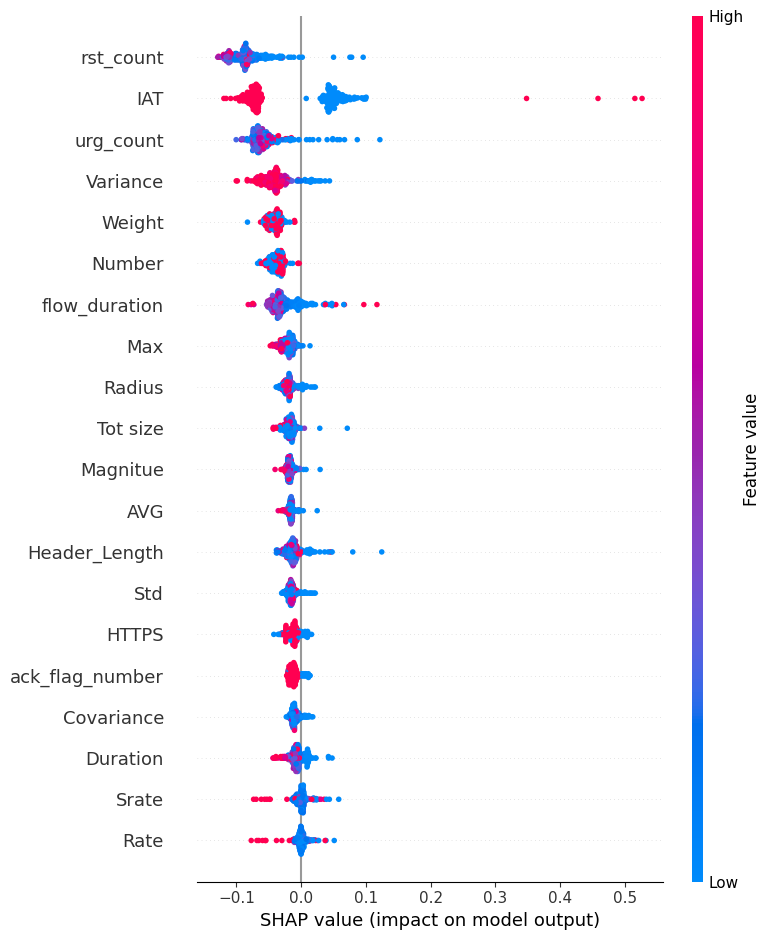

Saved: shap_summary_plot.png

Generating SHAP dependence plot for rst_count...


<Figure size 640x480 with 0 Axes>

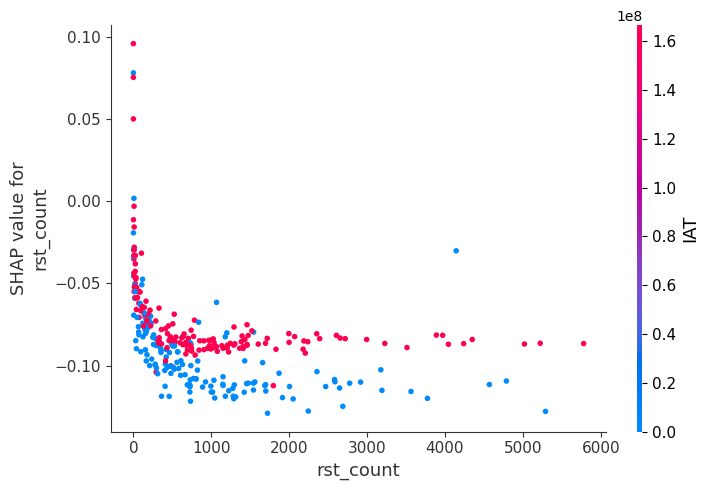

Saved: shap_dependence_rst_count.png

Generating SHAP dependence plot for IAT...


<Figure size 640x480 with 0 Axes>

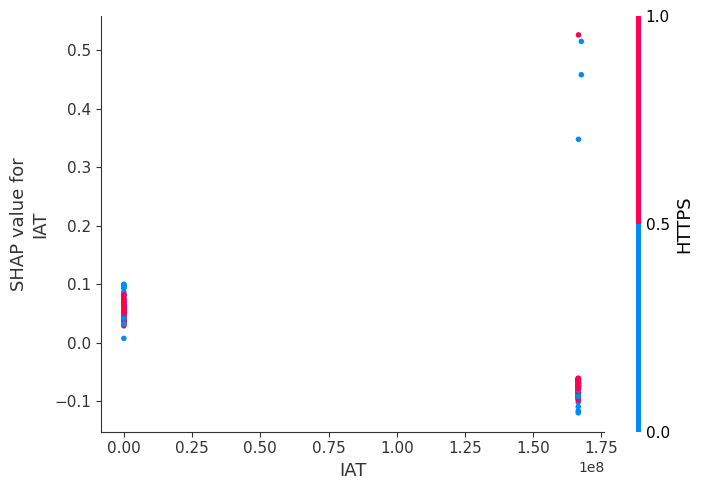

Saved: shap_dependence_IAT.png

Finding misclassified samples...
False positives found: 0
False negatives found: 0

All SHAP plots done!
Files saved: shap_summary_plot.png, shap_dependence_rst_count.png,
             shap_dependence_IAT.png, shap_force_false_positive.png,
             shap_force_false_negative.png


In [34]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import joblib

print("Running advanced SHAP analysis...")

# Reload RF model and data
rf = joblib.load("rf_model.pkl")
feature_columns = joblib.load("feature_columns.pkl")

# Rebuild attack-disjoint test set
ZERO_DAY_ATTACKS = {
    "SqlInjection", "XSS", "CommandInjection",
    "BrowserHijacking", "Uploading_Attack",
    "Backdoor_Malware", "DictionaryBruteForce"
}

chunks = []
total = 0
for chunk in pd.read_csv(TRAIN_PATH, chunksize=CHUNKSIZE):
    chunks.append(chunk)
    total += len(chunk)
    if total >= 600_000:
        break

df_shap = pd.concat(chunks, ignore_index=True).head(600_000)
df_shap["y"] = df_shap["label"].apply(lambda x: 0 if x == "BenignTraffic" else 1)

test_shap = df_shap[
    df_shap["label"].isin(ZERO_DAY_ATTACKS) |
    (df_shap["label"] == "BenignTraffic")
].head(200_000)

X_te_shap = test_shap.drop(columns=["label","y"], errors="ignore")
X_te_shap = X_te_shap.apply(pd.to_numeric, errors="coerce").fillna(0)
y_te_shap = test_shap["y"].astype(int)

# Use 300 samples for SHAP
sample_300 = X_te_shap.iloc[:300]
y_300 = y_te_shap.iloc[:300]

print("Computing SHAP values...")
explainer = shap.TreeExplainer(rf)
shap_vals = explainer.shap_values(sample_300)

# Handle format
if isinstance(shap_vals, list):
    sv = shap_vals[1]
else:
    sv = shap_vals[:, :, 1] if shap_vals.ndim == 3 else shap_vals

print("SHAP values computed!")
print(f"Shape: {sv.shape}")

# ── 1. SHAP Summary Plot (Beeswarm) ───────────────────────────────
print("\nGenerating SHAP summary plot...")
plt.figure()
shap.summary_plot(sv, sample_300, show=False)
plt.tight_layout()
plt.savefig("shap_summary_plot.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_summary_plot.png")

# ── 2. SHAP Dependence Plot - rst_count ───────────────────────────
print("\nGenerating SHAP dependence plot for rst_count...")
plt.figure()
shap.dependence_plot("rst_count", sv, sample_300, show=False)
plt.tight_layout()
plt.savefig("shap_dependence_rst_count.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_dependence_rst_count.png")

# ── 3. SHAP Dependence Plot - IAT ─────────────────────────────────
print("\nGenerating SHAP dependence plot for IAT...")
plt.figure()
shap.dependence_plot("IAT", sv, sample_300, show=False)
plt.tight_layout()
plt.savefig("shap_dependence_IAT.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_dependence_IAT.png")

# ── 4. Force Plot for misclassified samples ────────────────────────
print("\nFinding misclassified samples...")
preds_300 = rf.predict(sample_300)
proba_300 = rf.predict_proba(sample_300)[:, 1]

# Find false positives (predicted attack, actually benign)
fp_idx = np.where((preds_300 == 1) & (y_300.values == 0))[0]
# Find false negatives (predicted benign, actually attack)
fn_idx = np.where((preds_300 == 0) & (y_300.values == 1))[0]

print(f"False positives found: {len(fp_idx)}")
print(f"False negatives found: {len(fn_idx)}")

# Force plot for first false positive
if len(fp_idx) > 0:
    idx = fp_idx[0]
    print(f"\nForce plot - False Positive (sample {idx}):")
    print(f"True label: Benign | Predicted: Attack | Probability: {proba_300[idx]:.4f}")
    shap.force_plot(
        explainer.expected_value[1],
        sv[idx],
        sample_300.iloc[idx],
        matplotlib=True,
        show=False
    )
    plt.tight_layout()
    plt.savefig("shap_force_false_positive.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: shap_force_false_positive.png")

# Force plot for first false negative
if len(fn_idx) > 0:
    idx = fn_idx[0]
    print(f"\nForce plot - False Negative (sample {idx}):")
    print(f"True label: Attack | Predicted: Benign | Probability: {proba_300[idx]:.4f}")
    shap.force_plot(
        explainer.expected_value[1],
        sv[idx],
        sample_300.iloc[idx],
        matplotlib=True,
        show=False
    )
    plt.tight_layout()
    plt.savefig("shap_force_false_negative.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: shap_force_false_negative.png")

print("\nAll SHAP plots done!")
print("Files saved: shap_summary_plot.png, shap_dependence_rst_count.png,")
print("             shap_dependence_IAT.png, shap_force_false_positive.png,")
print("             shap_force_false_negative.png")

Finding misclassified samples from full test set...
False positives found: 246
False negatives found: 60

Force plot - False Positive:
True: Benign | Predicted: Attack | Prob: 0.7400


<Figure size 640x480 with 0 Axes>

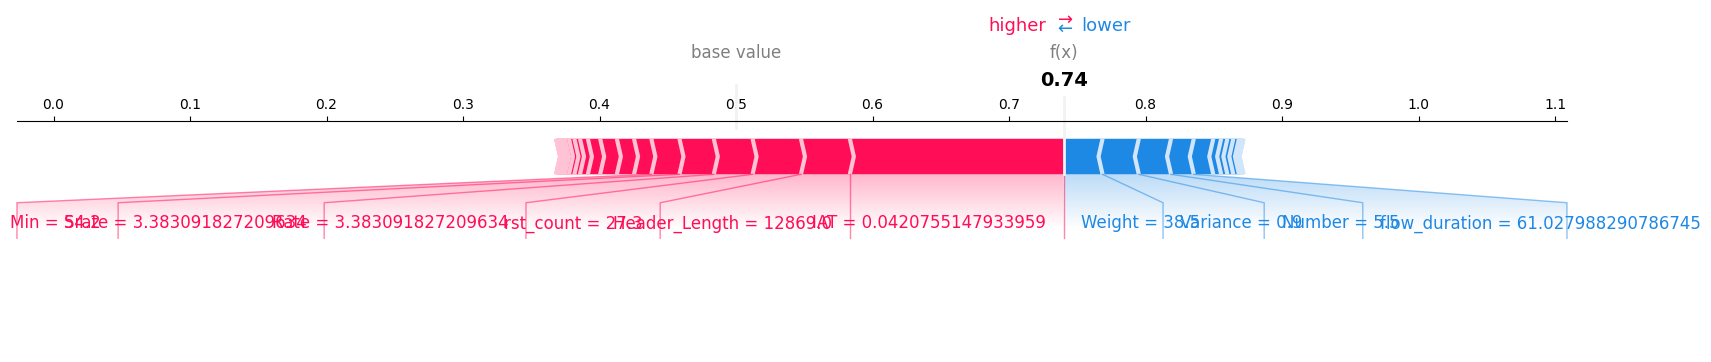

Saved: shap_force_false_positive.png

Force plot - False Negative:
True: Attack | Predicted: Benign | Prob: 0.4900


<Figure size 640x480 with 0 Axes>

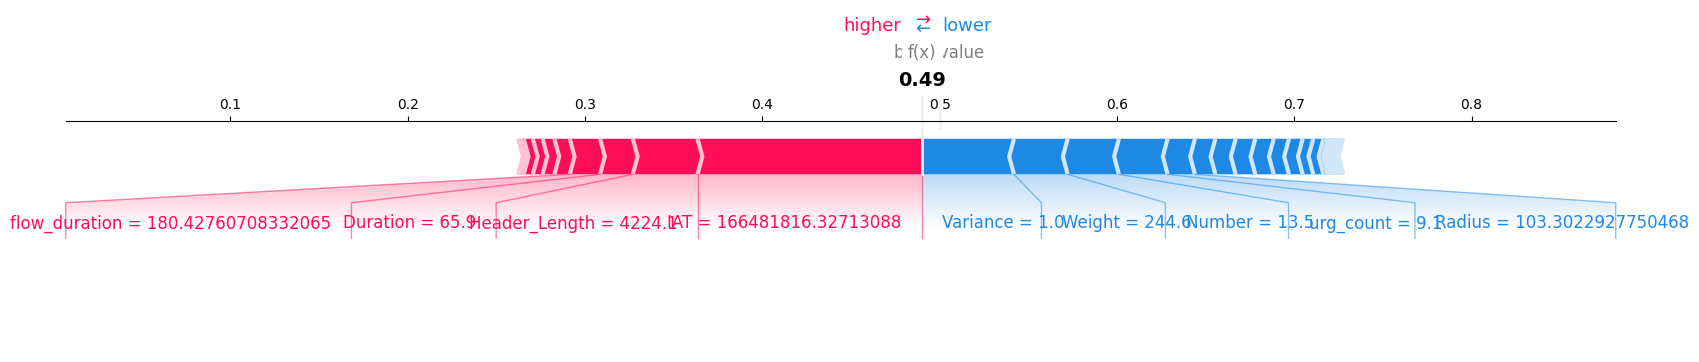

Saved: shap_force_false_negative.png

All force plots done!


In [35]:
print("Finding misclassified samples from full test set...")

# Use the full attack-disjoint test set
preds_full = rf.predict(X_te_shap)
proba_full = rf.predict_proba(X_te_shap)[:, 1]

# Find misclassified samples
fp_idx = np.where((preds_full == 1) & (y_te_shap.values == 0))[0]
fn_idx = np.where((preds_full == 0) & (y_te_shap.values == 1))[0]

print(f"False positives found: {len(fp_idx)}")
print(f"False negatives found: {len(fn_idx)}")

# Recompute SHAP for misclassified samples only
misclassified_idx = []
if len(fp_idx) > 0:
    misclassified_idx.append(fp_idx[0])
if len(fn_idx) > 0:
    misclassified_idx.append(fn_idx[0])

X_mis = X_te_shap.iloc[misclassified_idx]
shap_mis = explainer.shap_values(X_mis)

if isinstance(shap_mis, list):
    sv_mis = shap_mis[1]
else:
    sv_mis = shap_mis[:, :, 1] if shap_mis.ndim == 3 else shap_mis

# Force plot - False Positive
if len(fp_idx) > 0:
    print(f"\nForce plot - False Positive:")
    print(f"True: Benign | Predicted: Attack | Prob: {proba_full[fp_idx[0]]:.4f}")
    plt.figure()
    shap.force_plot(
        explainer.expected_value[1],
        sv_mis[0],
        X_mis.iloc[0],
        matplotlib=True,
        show=False
    )
    plt.savefig("shap_force_false_positive.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: shap_force_false_positive.png")

# Force plot - False Negative
if len(fn_idx) > 0:
    idx_mis = 1 if len(fp_idx) > 0 else 0
    print(f"\nForce plot - False Negative:")
    print(f"True: Attack | Predicted: Benign | Prob: {proba_full[fn_idx[0]]:.4f}")
    plt.figure()
    shap.force_plot(
        explainer.expected_value[1],
        sv_mis[idx_mis],
        X_mis.iloc[idx_mis],
        matplotlib=True,
        show=False
    )
    plt.savefig("shap_force_false_negative.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: shap_force_false_negative.png")

print("\nAll force plots done!")

In [36]:
# Check if timestamp column exists in the data
import pandas as pd

print("Checking for timestamp columns...")
chunk = pd.read_csv(TRAIN_PATH, nrows=5)
print(f"All columns: {list(chunk.columns)}")
print(f"\nTotal columns: {len(chunk.columns)}")

# Look for any time-related columns
time_cols = [c for c in chunk.columns if any(x in c.lower() 
             for x in ['time', 'date', 'stamp', 'hour', 'day', 'week'])]
print(f"\nTime-related columns found: {time_cols}")

# Show first few rows
print("\nFirst 3 rows:")
print(chunk.head(3))

Checking for timestamp columns...
All columns: ['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight', 'label']

Total columns: 47

Time-related columns found: []

First 3 rows:
   flow_duration  Header_Length  Protocol Type  Duration       Rate  \
0       0.000000         757.00           6.00     64.00  23.671858   
1       0.000000          54.00           6.00     64.00   2.393046   
2       0.033982          56.78           6.11     64.64   1.192715   

       Srate  Drate  fin_flag_number  syn_flag_number  rst_flag_number  

Generating confusion matrices for all models...
Data ready. Training models...
All models trained! Generating confusion matrices...


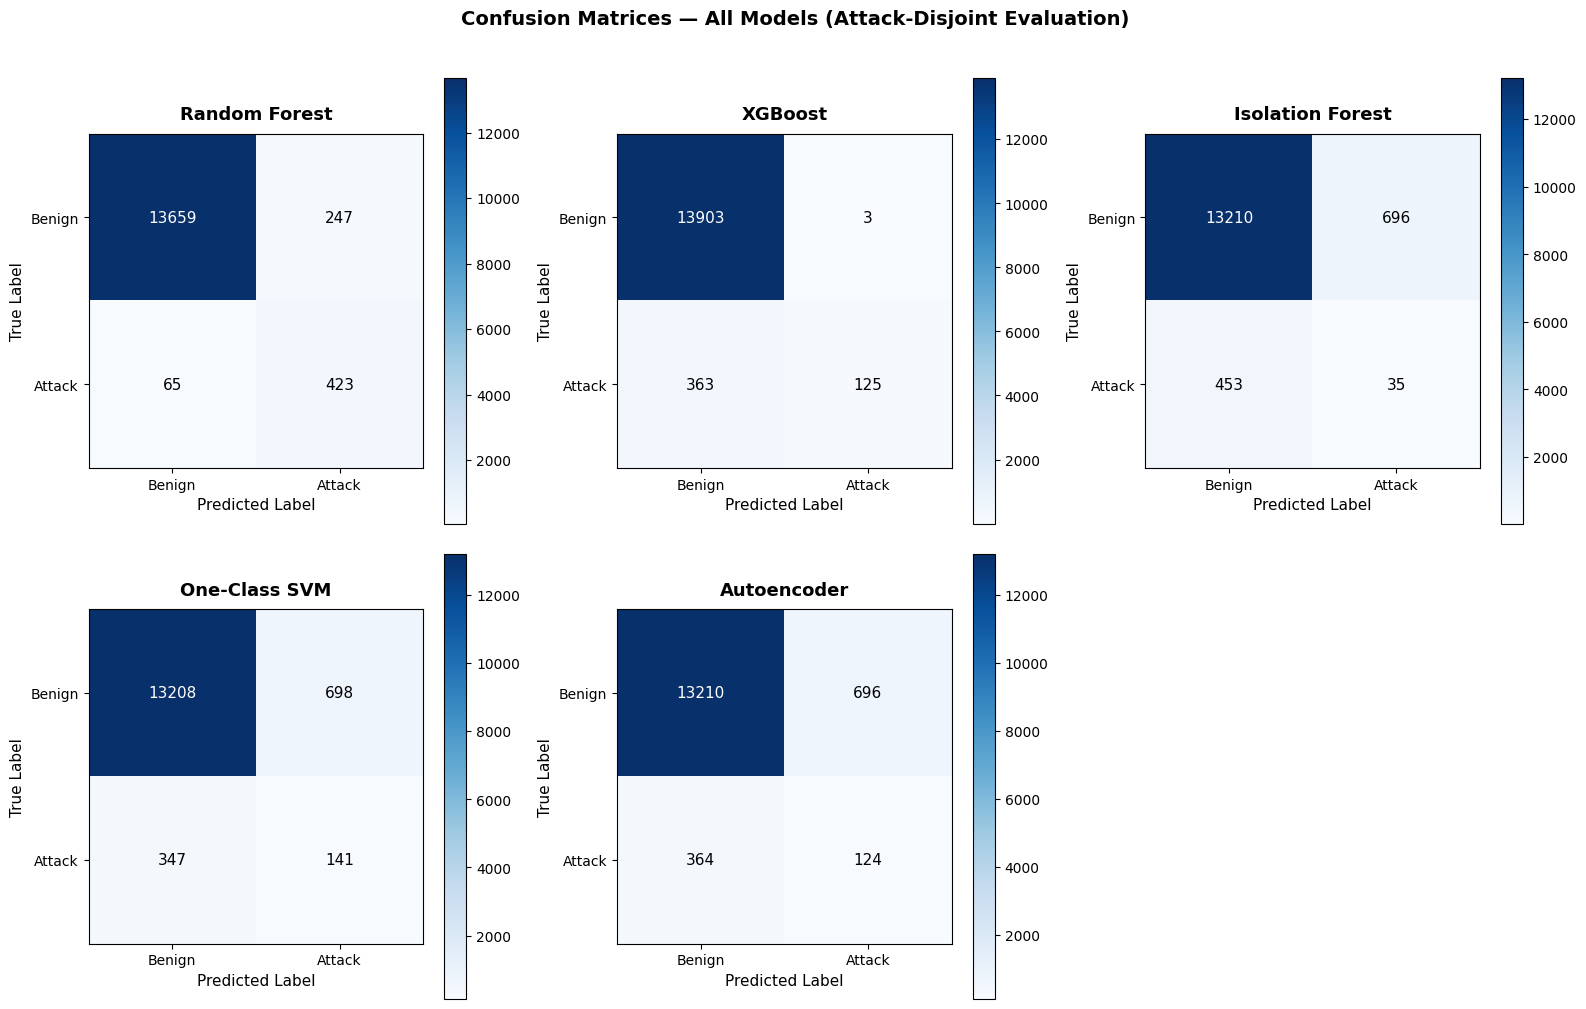

Saved: cm_all_models.png


In [37]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from sklearn.metrics import confusion_matrix

print("Generating confusion matrices for all models...")

# All models and their predictions on attack-disjoint test set
# We need to rebuild predictions - rerun attack-disjoint evaluation

# First rebuild the data
ZERO_DAY_ATTACKS = {
    "SqlInjection", "XSS", "CommandInjection",
    "BrowserHijacking", "Uploading_Attack",
    "Backdoor_Malware", "DictionaryBruteForce"
}

chunks = []
total = 0
for chunk in pd.read_csv(TRAIN_PATH, chunksize=CHUNKSIZE):
    chunks.append(chunk)
    total += len(chunk)
    if total >= 600_000:
        break

df_cm = pd.concat(chunks, ignore_index=True).head(600_000)
df_cm["y"] = df_cm["label"].apply(lambda x: 0 if x == "BenignTraffic" else 1)

train_cm = df_cm[~df_cm["label"].isin(ZERO_DAY_ATTACKS)].head(400_000)
test_cm  = df_cm[df_cm["label"].isin(ZERO_DAY_ATTACKS) |
                 (df_cm["label"] == "BenignTraffic")].head(200_000)

def prep(df):
    X = df.drop(columns=["label","y"], errors="ignore")
    X = X.apply(pd.to_numeric, errors="coerce").fillna(0)
    return X, df["y"].astype(int)

X_tr_cm, y_tr_cm = prep(train_cm)
X_te_cm, y_te_cm = prep(test_cm)

# Benign only for unsupervised
benign_cm = df_cm[df_cm["label"] == "BenignTraffic"].head(13906)
X_ben_cm = benign_cm.drop(columns=["label","y"], errors="ignore")
X_ben_cm = X_ben_cm.apply(pd.to_numeric, errors="coerce").fillna(0)

print("Data ready. Training models...")

# ── Train all models ───────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import tensorflow as tf

# Random Forest
rf_cm = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                random_state=42, n_jobs=-1)
rf_cm.fit(X_tr_cm, y_tr_cm)
rf_preds = rf_cm.predict(X_te_cm)

# XGBoost
xgb_cm = XGBClassifier(n_estimators=100, learning_rate=0.05,
                        scale_pos_weight=len(y_tr_cm[y_tr_cm==0])/len(y_tr_cm[y_tr_cm==1]),
                        eval_metric='logloss', random_state=42, n_jobs=-1)
xgb_cm.fit(X_tr_cm, y_tr_cm)
xgb_preds = xgb_cm.predict(X_te_cm)

# Isolation Forest
iso_cm = IsolationForest(n_estimators=100, contamination=0.05,
                          random_state=42, n_jobs=-1)
iso_cm.fit(X_ben_cm)
iso_preds = np.where(iso_cm.predict(X_te_cm) == -1, 1, 0)

# One-Class SVM
scaler_cm = StandardScaler()
X_ben_sc = scaler_cm.fit_transform(X_ben_cm)
X_te_sc  = scaler_cm.transform(X_te_cm)
svm_cm = OneClassSVM(kernel='rbf', nu=0.05)
svm_cm.fit(X_ben_sc)
svm_preds = np.where(svm_cm.predict(X_te_sc) == -1, 1, 0)

# Autoencoder
input_dim = X_ben_cm.shape[1]
encoder = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(input_dim,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
])
decoder = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(16,)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(input_dim, activation='linear'),
])
ae_cm = tf.keras.Sequential([encoder, decoder])
ae_cm.compile(optimizer='adam', loss='mse')
ae_cm.fit(X_ben_sc, X_ben_sc, epochs=10, batch_size=256,
          validation_split=0.1, verbose=0)
recon = ae_cm.predict(X_te_sc, verbose=0)
errors = np.mean(np.power(X_te_sc - recon, 2), axis=1)
ben_recon = ae_cm.predict(X_ben_sc, verbose=0)
ben_errors = np.mean(np.power(X_ben_sc - ben_recon, 2), axis=1)
threshold_ae = np.percentile(ben_errors, 95)
ae_preds = (errors > threshold_ae).astype(int)

print("All models trained! Generating confusion matrices...")

# ── Plot all confusion matrices ────────────────────────────────────
models = [
    ("Random Forest", rf_preds),
    ("XGBoost", xgb_preds),
    ("Isolation Forest", iso_preds),
    ("One-Class SVM", svm_preds),
    ("Autoencoder", ae_preds),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (name, preds) in enumerate(models):
    cm = confusion_matrix(y_te_cm, preds)
    ax = axes[i]
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set_title(f'{name}', fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Benign', 'Attack'], fontsize=10)
    ax.set_yticklabels(['Benign', 'Attack'], fontsize=10)
    for row in range(cm.shape[0]):
        for col in range(cm.shape[1]):
            ax.text(col, row, format(cm[row, col], 'd'),
                    ha="center", va="center", fontsize=11,
                    color="white" if cm[row, col] > cm.max()/2 else "black")
    plt.colorbar(im, ax=ax)

# Hide the 6th empty subplot
axes[5].set_visible(False)

plt.suptitle('Confusion Matrices — All Models (Attack-Disjoint Evaluation)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('cm_all_models.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: cm_all_models.png")

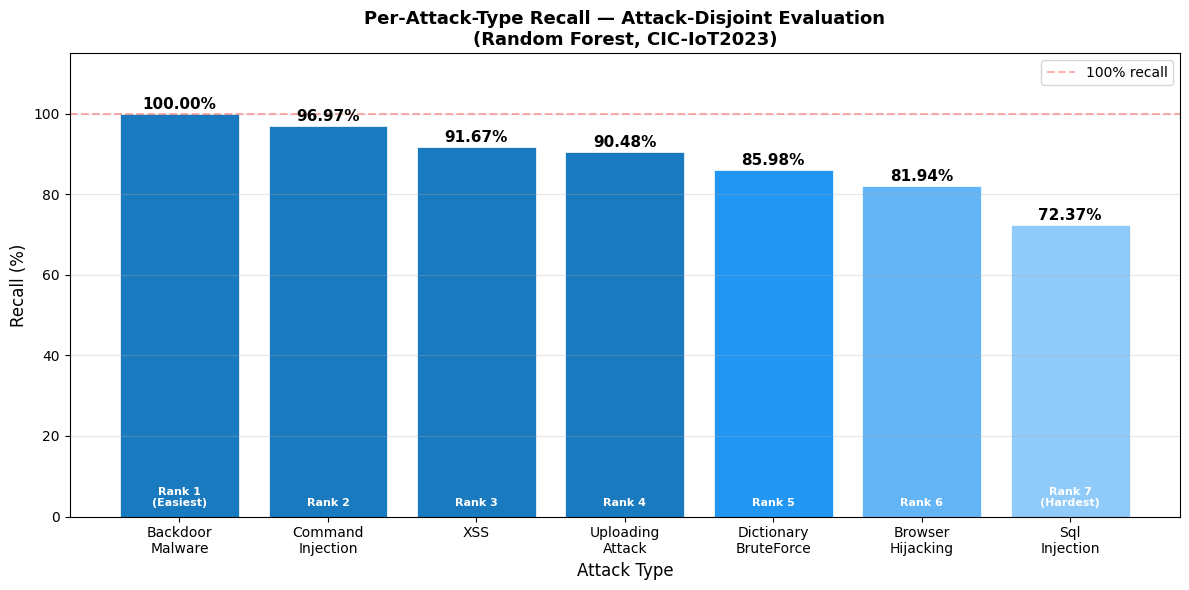

Saved: per_attack_recall.png


In [38]:
import matplotlib.pyplot as plt
import numpy as np

attack_types = [
    "Backdoor\nMalware",
    "Command\nInjection",
    "XSS",
    "Uploading\nAttack",
    "Dictionary\nBruteForce",
    "Browser\nHijacking",
    "Sql\nInjection"
]

recall_values = [100.00, 96.97, 91.67, 90.48, 85.98, 81.94, 72.37]
colors = ['#1a7abf' if r >= 90 else '#2196F3' if r >= 85 else '#64B5F6' 
          if r >= 80 else '#90CAF9' for r in recall_values]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(attack_types, recall_values, color=colors, 
              edgecolor='white', linewidth=0.5)

# Add value labels on bars
for bar, val in zip(bars, recall_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.2f}%', ha='center', va='bottom', 
            fontsize=11, fontweight='bold')

# Add difficulty rank labels
ranks = ["Rank 1\n(Easiest)", "Rank 2", "Rank 3", "Rank 4", 
         "Rank 5", "Rank 6", "Rank 7\n(Hardest)"]
for i, (bar, rank) in enumerate(zip(bars, ranks)):
    ax.text(bar.get_x() + bar.get_width()/2, 2,
            rank, ha='center', va='bottom',
            fontsize=8, color='white', fontweight='bold')

ax.set_xlabel('Attack Type', fontsize=12)
ax.set_ylabel('Recall (%)', fontsize=12)
ax.set_title('Per-Attack-Type Recall — Attack-Disjoint Evaluation\n(Random Forest, CIC-IoT2023)', 
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 115)
ax.axhline(y=100, color='red', linestyle='--', alpha=0.3, label='100% recall')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('per_attack_recall.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: per_attack_recall.png")